<h1><b><center>Downloading and Handling DEMs using GeoidLab</center></b></h1>
<p style="text-align: center; font-size: 1.2em; color: white;">
    Author: Caleb Kelly<br>
</p>

`GeoidLab` has a dedicated module for accessing DEM in general and specifically for preprocessing DEMs for ingestion into subsequent `GeoidLab` pipelines (e.g., terrain modeling).

This tutorial demonstrate how to use `dem.py` module to access and preprocess a DEM using `GeoidLab`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from geoidlab import dem as dem_func

# Colormaps

Let's copy and paste a useful function from `geoidlab.cli.commands.plot` for using custom colormaps. This function allows us to use GMT colormaps, our own custom `rainbow` colormap (although this is not much different from GMT_rainbow.cpt), and all of the Matplotlitb's colormaps. To use a colormap, say `viridis`, instead of passing `'viridis'` to `cmap` in the matplotlib call, pass `cmap=get_colormap('viridis')`. This makes more sense if you are using custom colormaps: `cmap=get_colormap('GMT_rainbow.cpt')`.

In [3]:
from geoidlab.mapping.colormaps import bright_rainbow_cmap, cpt_cmap
from matplotlib.colors import Colormap, ListedColormap
import matplotlib.pyplot as plt

CUSTOM_CMAPS: dict[str, ListedColormap] = {
    'bright_rainbow': bright_rainbow_cmap()
}

def get_colormap(cmap_name: str) -> Colormap:
    '''Retrieve colormap by name, handling custom and GMT .cpt colormaps'''
    if cmap_name in CUSTOM_CMAPS:
        return CUSTOM_CMAPS[cmap_name]
    elif cmap_name.endswith('.cpt'):
        return cpt_cmap(cmap_name)
    else:
        try:
            return plt.get_cmap(cmap_name)
        except ValueError:
            raise ValueError(f'Invalid colormap: {cmap_name}. Use --list-cmaps to see available options.')

# DEM

If you goal is geoid/terrain computation, you only really need to interact with `dem_func.dem4geoid`. This is designed to preprocess the DEM for ingestion into the geoid/terrain computation pipeline. For a hustle free way of downloading DEMs for other applications, there are specific modules that can download the raw DEM over your area of interest without any preprocessing.

- `download_dem_cog`: this function access and downloads DEMs that are stored as Cloud Optimized GeoTiffs. This allows us to simply download the DEM of interest over our study region, without needing to download the entire DEM file. This also downloads without preprocessing for other `GeoidLab` functionalities. Supported DEMs are: SRTM, Copernicus DEM, GEBCO, and NASADEM.

- `download_srtm30plus`: this function handles the downloading of SRTM30PLUS topography/bathymetry tiles over the region of interest, without additional preprocessing.

Note that an optional `bbox_off` parameter controls whether to download the DEM over a region larger than the area of interest (AOI). For instance, `bbox_off=1` will download data covering an area 1 degree larger than the specified AOI (`bbox`). This is especially useful for terrain quantities in accounting for the influence of the gravitational attraction of neighboring topography.

We will start with `dem4geoid`.

In [4]:
help(dem_func.dem4geoid)

Help on function dem4geoid in module geoidlab.dem:

dem4geoid(bbox, ncfile=None, url=None, cog_url=None, bbox_off=1, downloads_dir=None, resolution=30, model='srtm30plus', interp_method='slinear', lon_name='x', lat_name='y', height_name='z') -> xarray.core.dataset.Dataset
    Prepare a DEM for geoid calculation.

    Parameters
    ----------
    bbox          : bounding box of area of interest
                    [xmin, xmax, ymin, ymax]
                    [left, right, bottom, top]
                    [W, E, S, N]
    ncfile        : path to DEM netCDF file
    url           : URL to a custom remote DEM file that should be downloaded locally first
    cog_url       : URL to a cloud-optimized or GDAL-readable remote DEM
    bbox_off      : offset for bounding box (in degrees)
    downloads_dir : directory to download the file to
    resolution    : Resolution to resample the DEM
    model         : name of the DEM model
                     - srtm30plus
                     - srtm
  

In [5]:
bbox = [0, 6, 44, 48]
bbox_off = 0
model = 'srtm30plus'

dem = dem_func.dem4geoid(bbox=bbox, downloads_dir='GeoidProject/downloads', model=model, bbox_off=bbox_off)

w020n90.nc exists and covers bbox. Using local copy.

Creating xarray dataset of DEM with buffer of 0 degree(s)

Aligning DEM to bounding box and resampling DEM to 30 arc-seconds...
DEM alignment and resampling completed in 0.81 seconds.



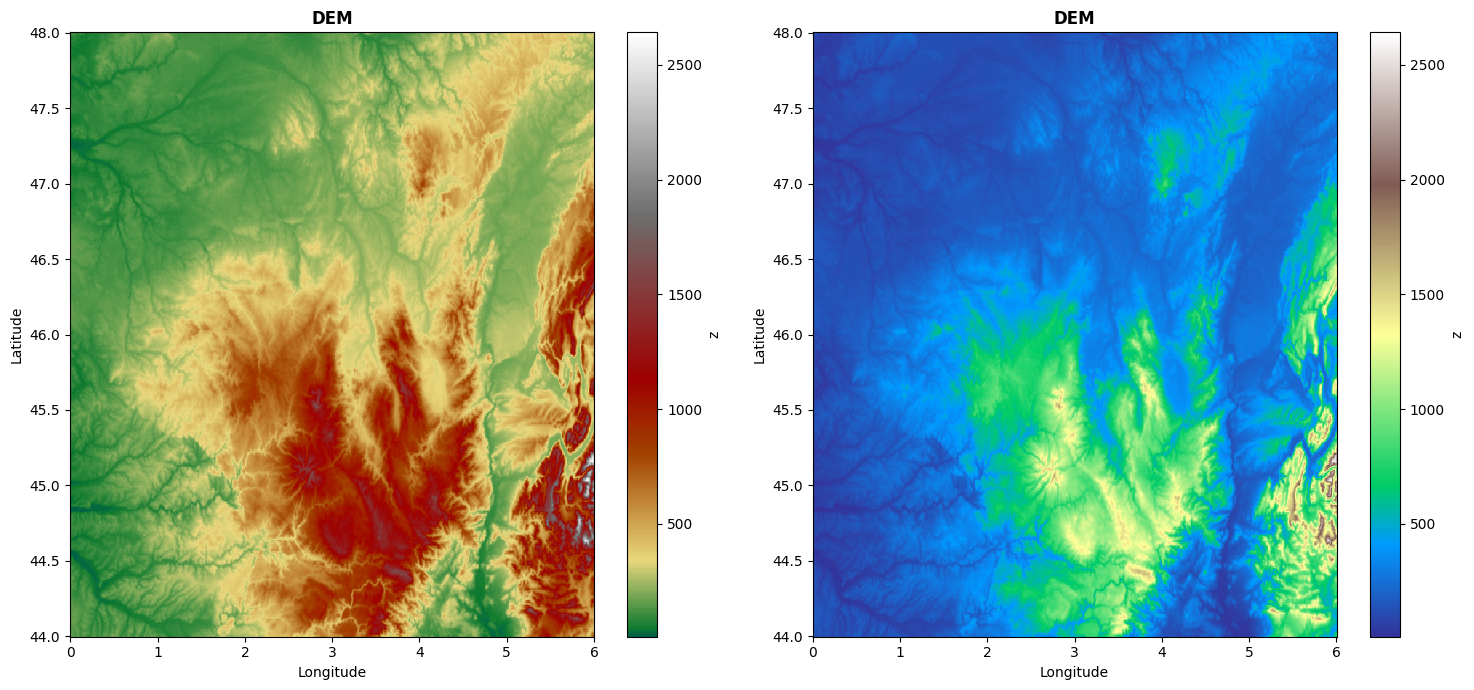

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
dem['z'].plot(cmap=get_colormap('DEM_poster.cpt'), ax=axs[0])

dem['z'] = dem['z'].where(dem['z'] >= 0, np.nan)
dem['z'].plot(cmap='terrain', ax=axs[1])

for ax in axs:
    ax.set_title('DEM', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
# axs[1].set_ylim(bottom=4)

plt.tight_layout()
plt.show()

Let's have a look at the other two functions

In [7]:
dem_func.download_srtm30plus?

Signature: dem_func.download_srtm30plus(url=None, downloads_dir=None, bbox=None) -> str
Docstring:
Download SRTM30PLUS from https://topex.ucsd.edu/pub/srtm30_plus/srtm30/grd/

Parameters
----------
url           : URL of the srtm30plus tile, or a list of URLs if bbox spans multiple tiles.
downloads_dir : Directory to download the file(s) to.
bbox          : Bounding box of the area of interest (to be provided if url is not provided).

Returns
-------
merged_filepath : str
    Filepath of the merged DEM file if multiple tiles were downloaded.
File:      ~/Documents/Github/geoidlab/geoidlab/dem.py
Type:      function

Since we specified `model=srtm30plus` in the previous example and we are using the same download directory, `GeoidLab` will check the existing file to see if it is fully downloaded and correct. If yes, it skips redownloading. Otherwise, it will redownload. Note also that `dem4geoid` does not write the preprocessed DEM to file. So the downloaded file is the raw DEM file over the specified `bbox` + `bbox_off`. `download_srtm30plus` doesn't have the `bbox_off` parameter. If the requested area falls in multiple tiles, it downloads all the relevant tiles.

In [8]:
bbox = [0, 6, 44, 48]

dem = dem_func.download_srtm30plus(downloads_dir='GeoidProject/downloads', bbox=bbox)

w020n90.nc exists, is readable, and covers bbox. Using local copy.



Notice that `GeoidLab` tells us that the file exists, is readable, and covers the bbox. Then it skips download. We will not replot since it is the same as the above. Next, we move on to accessing a COG

In [9]:
help(dem_func.download_dem_cog)

Help on function download_dem_cog in module geoidlab.dem:

download_dem_cog(bbox, model=None, cog_url=None, bbox_off=2, resolution=30, downloads_dir=None, interp_method='slinear') -> xarray.core.dataset.Dataset
    Download DEM using Cloud Optimized GeoTIFF (COG) format
    from OpenTopography.

    Parameters
    ----------
    bbox          : bbox of the area of interest (W, E, S, N)
    model         : name of the DEM model
                     - srtm
                     - cop
                     - nasadem
                     - gebco
    cog_url       : url of the COG
    downloads_dir : directory to download the file to
    bbox_off      : offset for bounding box (in degrees)
    resolution    : resolution to resample the DEM (in seconds)
    interp_method : interpolation method for resampling

    Returns
    -------
    dem           : xarray dataset of the DEM

    Notes
    -----
    1. OpenTopography hosts other DEMs that are not included here.
    2. You can see the list o

We are going are going to specify the resolution to reduce the download time. The docstring says that the `resolution` parameter must be provided in seconds. We are going to specify `resolution` as $0.02\degree$, which the degree value multiplied by 3600. This may take time depending on internet connectivity. We are going to download the Copernicus DEM. Options for `model` parameter are:

- srtm
- cop
- nasadem
- gebco


In [11]:
bbox = [0, 6, 44, 48]
bbox_off = 0
model = 'cop'
resolution = 0.02 * 3600  # 0.02 degrees in arcseconds

dem_cog = dem_func.download_dem_cog(bbox=bbox, model=model, bbox_off=bbox_off, resolution=resolution, downloads_dir='GeoidProject/downloads')

Accessing COP COG at https://opentopography.s3.sdsc.edu/raster/COP90/COP90_hh.vrt

COG access completed in 3.25 seconds.
Creating DEM from COP COG...
DEM created successfully in 42.48 seconds!

Saving DEM to /Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/downloads/cop_dem.nc...


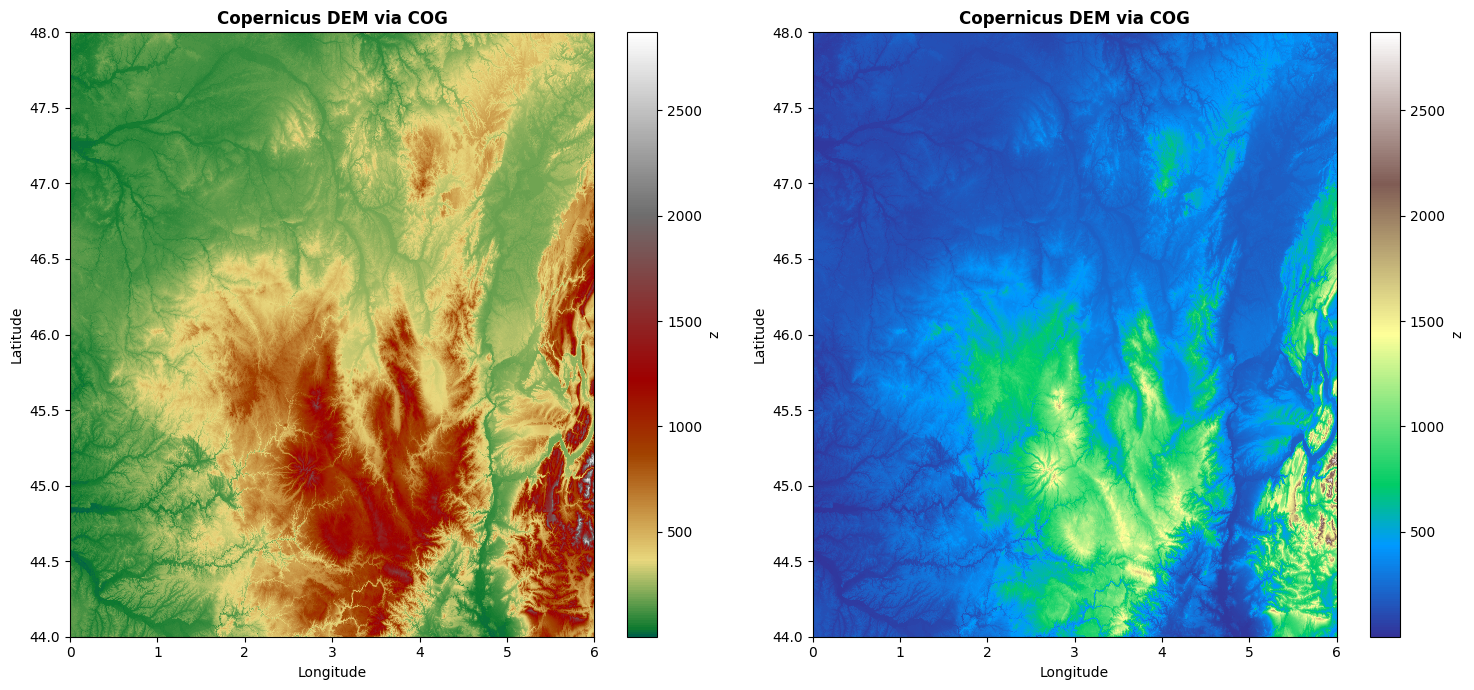

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
dem_cog['z'].plot(cmap=get_colormap('DEM_poster.cpt'), ax=axs[0])

dem_cog['z'] = dem_cog['z'].where(dem_cog['z'] >= 0, np.nan)
dem_cog['z'].plot(cmap='terrain', ax=axs[1])

for ax in axs:
    ax.set_title('Copernicus DEM via COG', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
# axs[1].set_ylim(bottom=4)

plt.tight_layout()
plt.show()

# CUSTOM DEMs

For users seeking to use custom DEMs, `dem.py` allows this. `dem4geoid` specifically allows users to pass a NetCDF file that will then be formatted for geoidlab ingestion. Alternatively, users may leverage the COG functionalities of `dem.py` by simply specifying a URL or the generic `download_custom_dem` for non-COG URLs. `geoidlab` will then attempt to access this DEM file. Here's an example using GEBCO URL. Note that this is not the same as simply specifying the model name. 

In [13]:
bbox = [0.01, 5.99, 44.01, 47.99]
url = 'https://opentopography.s3.sdsc.edu/raster/GEBCOIceTopo/GEBCOIceTopo.vrt'
dem1 = dem_func.download_dem_cog(cog_url=url, bbox=bbox, bbox_off=0, downloads_dir='GeoidProject/downloads', resolution=0.02*3600)
dem1

Accessing CUSTOM COG at https://opentopography.s3.sdsc.edu/raster/GEBCOIceTopo/GEBCOIceTopo.vrt

COG access completed in 1.40 seconds.
Creating DEM from CUSTOM COG...
DEM created successfully in 4.67 seconds!

Saving DEM to /Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/downloads/GEBCOIceTopo_dem.nc...


<xarray.Dataset> Size: 11MB
Dimensions:      (x: 1436, y: 956)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 11kB 0.01042 0.01458 0.01875 ... 5.981 5.985 5.99
  * y            (y) float64 8kB 47.99 47.99 47.98 47.98 ... 44.02 44.01 44.01
    spatial_ref  int64 8B 0
Data variables:
    z            (y, x) float64 11MB 107.0 114.0 109.0 ... 610.0 637.0 658.0
Attributes:
    date_created:  2026-03-18 17:39:44 Asia/Shanghai
    created_by:    GeoidLab
    website:       https://github.com/cikelly/geoidlab
    copyright:     Copyright (c) 2026, Caleb Kelly

As you can see, `geoidlab` correctly identifies that a user has specified a custom DEM and successfully downloads this. 

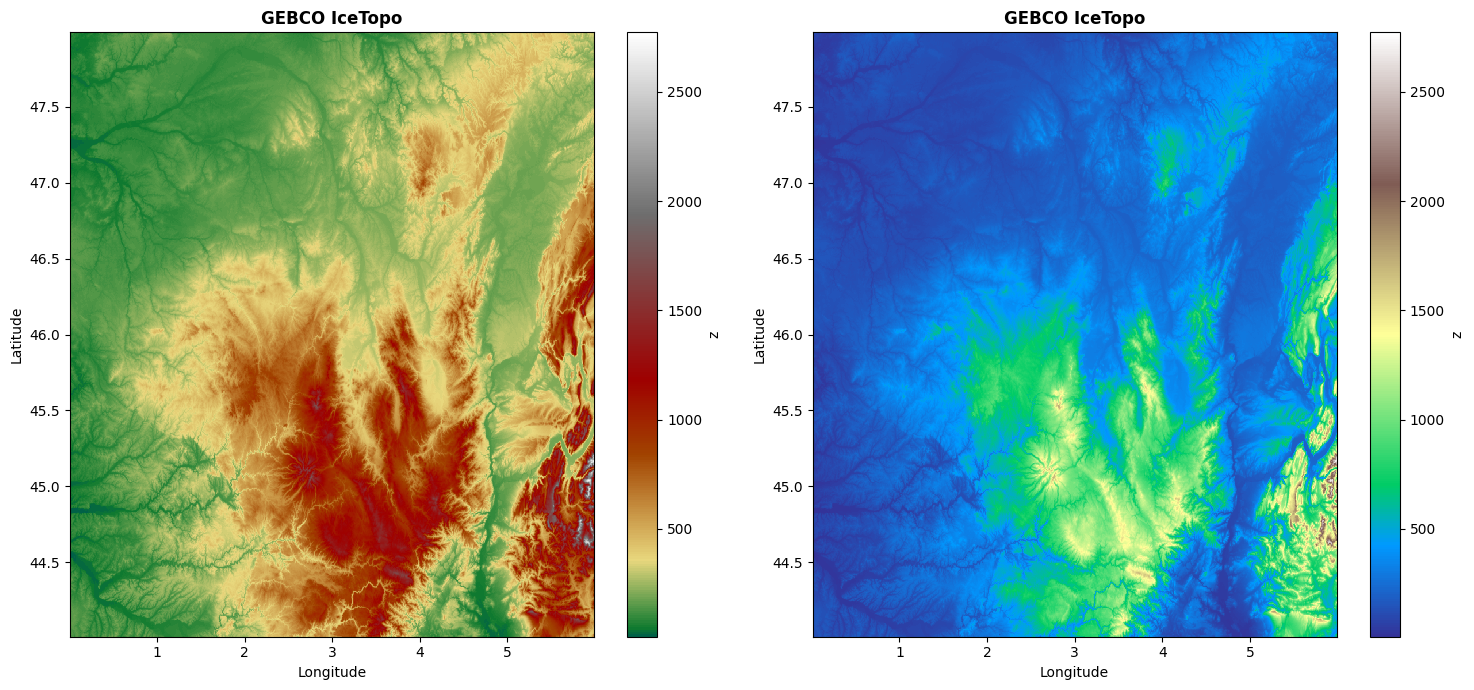

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
dem1['z'].plot(cmap=get_colormap('DEM_poster.cpt'), ax=axs[0])

dem1['z'] = dem1['z'].where(dem1['z'] >= 0, np.nan)
dem1['z'].plot(cmap='terrain', ax=axs[1])

for ax in axs:
    ax.set_title('GEBCO IceTopo', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
# axs[1].set_ylim(bottom=4)

plt.tight_layout()
plt.show()

Next, we will pass a NetCDF file to `dem4geoid` and `dem4geoid` should format it for `geoidlab` ingestion. For this example, we will set our target resolution to 90 arc-seconds, coarser than the original 72 arc-seconds (0.02 degrees).

In [15]:
ncfile = '/Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/downloads/GEBCOIceTopo_dem.nc'

dem1 = dem_func.dem4geoid(ncfile=ncfile, bbox=[0.01, 5.99, 44.01, 47.99], bbox_off=0, resolution=90, lon_name='x', lat_name='y', height_name='z')

Creating xarray dataset of DEM with buffer of 0 degree(s)

Aligning DEM to bounding box and resampling DEM to 90 arc-seconds...
DEM alignment and resampling completed in 0.02 seconds.



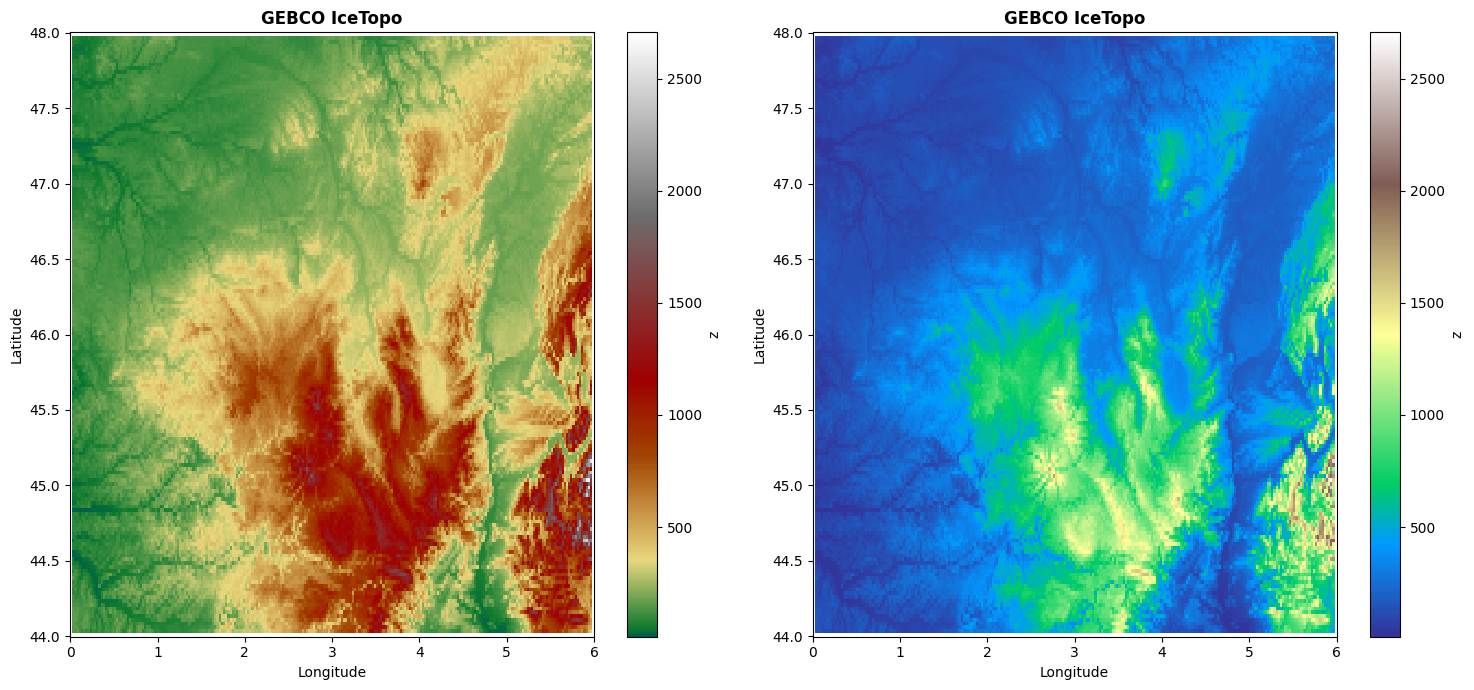

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
dem1['z'].plot(cmap=get_colormap('DEM_poster.cpt'), ax=axs[0])

dem1['z'] = dem1['z'].where(dem1['z'] >= 0, np.nan)
dem1['z'].plot(cmap='terrain', ax=axs[1])

for ax in axs:
    ax.set_title('GEBCO IceTopo', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
# axs[1].set_ylim(bottom=4)

plt.tight_layout()
plt.show()

Now, we will test downloading a local DEM that is hosted on GitHub. This is the same GEBCOIceTopo_dem.nc that we downloaded in the previouos example

In [17]:
url = 'https://github.com/cikelly/geoidlab-tutorial/blob/main/tutorials/GeoidProject/downloads/GEBCOIceTopo_dem.nc'
dem1 = dem_func.download_custom_dem(url=url, downloads_dir='GeoidProject/downloads', filename='GEBCOIceTopo_dem1.nc')
dem1

	/Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/downloads/GEBCOIceTopo_dem1.nc ...


100%|██████████| 11.0M/11.0M [00:00<00:00, 11.1MiB/s]

PosixPath('/Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/downloads/GEBCOIceTopo_dem1.nc')

**PS**: For each of the supported DEM options, `GeoidLab` saves the downloads with a unique name. This means that specifying a different model does not overwrite previous downloads. However, for the same model (except `srtm30plus`), `GeoidLab` automatically overwrites existing files if the bbox is not contained within the available file.

# DEM CLI

`GeoidLab` comes packed with CLI tools that make life easy. You don't need to open a Notebook. You only need a Terminal window. If you use conda/virtual environments to manage your packages, remember to activate the environment where `geoidlab` is installed.

**IMPORTANT**
- If you are running the CLI commands below, remove the `!` character. This is required in ipynb to run Unix commands. You don't need this in Terminal
- The CLI tool only provides access to `dem4geoid`!

In [21]:
!geoidlab -h

usage: geoidlab [-h] [-v] [-c [CONFIG]] {ggm,topo,reduce,viz,geoid,ncinfo} ...

GeoidLab: A toolkit for geodetic computations including gravity reductions,
terrain quantities, GGM synthesis, geoid computation, and visualization.

options:
  -h, --help            show this help message and exit
  -v, --version         show program's version number and exit
  -c [CONFIG], --config [CONFIG]
                        Path to configuration file (e.g., geoidlab.cfg). If
                        not provided, copies from geoidlab/docs/geoidlab.cfg
                        to the current directory.

subcommands:
  {ggm,topo,reduce,viz,geoid,ncinfo}
    ggm                 Synthesize gravity field functionals from a global
                        geopotential model (GGM)
    topo                Compute topographic quantities from a Digital
                        Elevation Model (DEM)
    reduce              Perform gravity reduction (Free-air, Bouguer, Helmert)
    viz                 Visualize da

For DEM and topographic quantities, we are interested in the `topo` subcommand. We can access it via `geoidlab topo`. Remember to start with `!` in Jupyter Notebooks

In [22]:
!geoidlab topo -h

usage: geoidlab topo [-h] --topo TOPO -b BBOX BBOX BBOX BBOX
                     [--ref-topo REF_TOPO] [--dtm-nmax DTM_NMAX]
                     [--dtm-chunk-size DTM_CHUNK_SIZE] [-md MODEL_DIR]
                     [--radius RADIUS] [-ell ELLIPSOID]
                     [--do {download,terrain-correction,indirect-effect,rtm-anomaly,height-anomaly,site,atm-corr,all}]
                     [-s {download,terrain-correction,indirect-effect,rtm-anomaly,height-anomaly,site,atm-corr}]
                     [-e {download,terrain-correction,indirect-effect,rtm-anomaly,height-anomaly,site,atm-corr}]
                     [-pn PROJ_NAME] [-bo BBOX_OFFSET] [-gs GRID_SIZE]
                     [-gu {degrees,minutes,seconds}]
                     [--window-mode {radius,fixed}] [-p]
                     [--chunk-size CHUNK_SIZE]
                     [--interpolation-method {linear,nearest,slinear,cubic,quintic}]
                     [--atm-method {noaa,ngi,wenzel}] [--variable-density]
              

Let's download SRTM30PLUS over the same bbox. By default, the CLI will create a project folder with name supplied by `-pn` flag. This defaults to `GeoidProject` if unspecified. To avoid redownloading the tile, we are going to move `downloads` into `GeoidProject` directory/

**PS**
I have updated `downloads` to `GeoidProject/downloads` in the preceding code cells, but have not updated the corresponding Markdown cells. Don't let this confuse you :).

In [25]:
from pathlib import Path
Path('GeoidProject').mkdir(exist_ok=True)

# Move downloads directory into GeoidProject
if Path('downloads').exists():
    Path('downloads').rename(Path('GeoidProject') / 'downloads')

In [29]:
!geoidlab topo --topo srtm30plus -b 0 6 44 48 -bo 0 --do download

********************************************************************************************************************
                                           Subcommand: topo
********************************************************************************************************************
w020n90.nc exists and covers bbox. Using local copy.

Creating xarray dataset of DEM with buffer of 0.0 degree(s)

Aligning DEM to bounding box and resampling DEM to 30 arc-seconds...
DEM alignment and resampling completed in 0.29 seconds.

No computation tasks specified.


Wonderful! Now let's look at using the CLI to make figures. This is handled by the `viz` subcommand, accessible via `geoidlab viz`

In [30]:
!geoidlab viz -h

usage: geoidlab viz [-h] [-f FILENAME [FILENAME ...]] [-v VARIABLE]
                    [-c CMAP [CMAP ...]] [--fig-size FIG_SIZE FIG_SIZE]
                    [--vmin VMIN] [--vmax VMAX] [--font-size FONT_SIZE]
                    [--title TITLE [TITLE ...]]
                    [--title-font-size TITLE_FONT_SIZE]
                    [--font-family FONT_FAMILY] [--cbar-title CBAR_TITLE]
                    [--list-cmaps] [--save] [--dpi DPI] [-pn PROJ_NAME]
                    [--xlim XLIM XLIM] [--ylim YLIM YLIM] [--scalebar]
                    [--scalebar-units {km,degrees}] [--scalebar-fancy]
                    [-u {m,cm,mm}] [--boundary BOUNDARY]
                    [--bound-color BOUND_COLOR]
                    [--bound-linewidth BOUND_LINEWIDTH] [--sharex] [--sharey]
                    [--nrows NROWS] [--ncols NCOLS] [--global-plot]
                    [--projection {PlateCarree,Robinson,Mollweide}]
                    [--global-cbar-orientation {horizontal,vertical}]
       

We need to specify the file path using the `-f` or `--filename` flag. If you figure out how to display the map in the Notebook, leave a comment. For now, we will pass the `--save` flag to save the figure to file. This should be in the `{-pn}/results/figures` directory. In this case `GeoidProject/results/figures`.

In [37]:
!geoidlab viz -f GeoidProject/downloads/cop_dem.nc --cmap DEM_poster.cpt --save --title "Auvergne COP DEM" --cbar-title "Elevation (m)" --dpi 100

********************************************************************************************************************
                                           Subcommand: viz
********************************************************************************************************************
Figure saved to: /Users/kelly/Documents/Github/geoidlab-tutorial/tutorials/GeoidProject/results/figures/cop_dem.png


<img src="GeoidProject/results/figures/cop_dem.png" 
     width="700" 
     alt="Terrain correction result using constant crustal density" 
     style="display: block; margin: auto;">